# Multiple Linear Regression ML Model EXAMPLE
The goal of this project is to understand how social media usage can effect academic performance. We will be using a multiple linear regressiona model that will compare:
Social media platform, time spent daily, stress level, sleep hours, physical activity.
***

## 1. Install SciKit Learn

In [35]:
%pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Import Libraries

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## 3. Check That SciKit-Learn Works

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
print("scikit-learn is working")

scikit-learn is working


## 4. Create or Import Training Data
Here you can feed data from other csv files, lists etc

In [8]:
df = pd.read_csv("04.5-teen-social-media-health-data.csv")

In [9]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


 # Mapping Social Interaction Column to Integers
The model cannot work with strings, so all strings must be mapped.

In [13]:
level_map = {
    "low": 1,
    "medium": 2,
    "high": 3
}

df["social_interaction_level"] = df["social_interaction_level"].map(level_map)

# Get the columns and put them in a list
Important, this needs to happen in order to format our data for the next part
x = data we will use to train the model
y = thing you want to predict

In [32]:
features = [
    "age",
    "daily_social_media_hours",
    "sleep_hours",
    "screen_time_before_sleep",
    "physical_activity",
    "social_interaction_level",
    "stress_level",
    "anxiety_level",
    "addiction_level"
]
x_train = df[features]
y_train = df["academic_performance"]

In [15]:
display(x_train)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
0,14,7.9,7.4,2.9,1.5,1,2,2,1
1,19,1.9,8.0,2.9,0.8,3,8,1,10
2,17,1.3,7.6,0.5,0.0,3,2,4,2
3,15,7.4,6.9,1.6,0.8,2,1,7,9
4,15,4.7,4.9,3.0,1.4,2,3,5,2
...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,1.0,1,3,4,4
1196,16,2.3,8.0,1.9,0.4,3,7,4,4
1197,14,1.7,8.7,0.7,0.8,3,1,1,1
1198,15,3.9,8.5,2.1,0.6,3,7,9,9


## 5. Create the Model

In [16]:
model = LinearRegression()

## 6. Train the Model and Find the Weights

The model finds the best-fit equation by choosing weights and a bias that make the prediction error as small as possible.

In [17]:
model.fit(x_train, y_train) # finds the best-fit equation

for feature, weight in zip(features, model.coef_):
    print(f"{feature} weight: {weight:.6f}")

print(f"Bias: {model.intercept_:.2f}")

age weight: -0.003127
daily_social_media_hours weight: 0.004760
sleep_hours weight: 0.009301
screen_time_before_sleep weight: -0.028831
physical_activity weight: 0.019306
social_interaction_level weight: -0.002089
stress_level weight: -0.000128
anxiety_level weight: -0.013150
addiction_level weight: 0.006943
Bias: 3.03


## 9. Graph all Features Against Academic Peformance

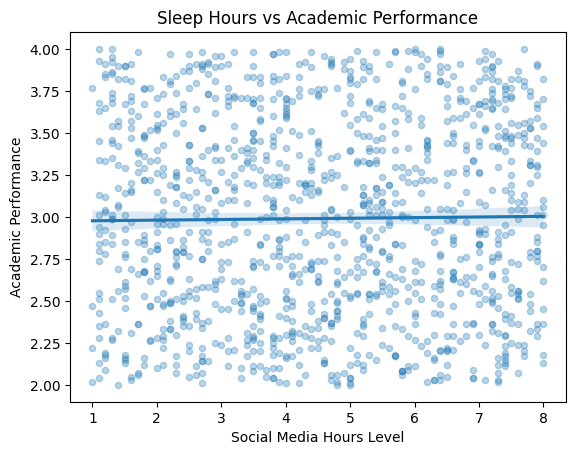

In [40]:
sns.regplot(
    data=df,
    x="daily_social_media_hours",
    y="academic_performance",
    scatter_kws={"alpha": 0.3, "s": 20}
)

plt.title("Sleep Hours vs Academic Performance")
plt.xlabel("Social Media Hours Level")
plt.ylabel("Academic Performance")
plt.show()

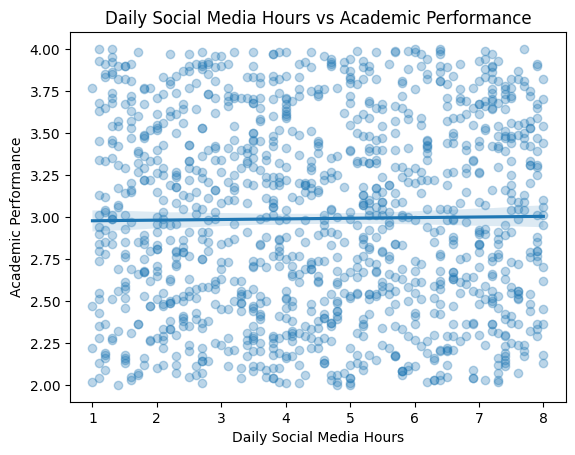

In [26]:
sns.regplot(
    data=df,
    x="daily_social_media_hours",
    y="academic_performance",
    scatter_kws={"alpha": 0.3}
)

plt.title("Daily Social Media Hours vs Academic Performance")
plt.xlabel("Daily Social Media Hours")
plt.ylabel("Academic Performance")
plt.show()

## 10. Make a Prediction

In [ ]:
# New house: 1500 sqft, 4 bedrooms, 1 floor, 40 years old
new_house = [[1500, 4, 1, 40]]

prediction = model.predict(new_house)

estimated_price = prediction[0] * 1000

print(f"Estimated House Price: ${estimated_price:,.2f}")

In [41]:
model.score(x_train, y_train)

0.007791439038076997